# 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

FIGURES_PATH = "../outputs/figures/"
MODELS_PATH  = "../src/"

# 2. Cargado y filtrado

In [2]:
df = pd.read_csv("../data/raw/dataset.csv")
df.drop_duplicates().dropna()

# Filtrar canciones con popularidad 0
df = df[df['popularity'] > 0]

print(f"Shape tras filtrar popularidad 0: {df.shape}")
print(f"Popularidad media: {df['popularity'].mean():.1f}")


Shape tras filtrar popularidad 0: (97980, 21)
Popularidad media: 38.7


# 3. Feature Engineering

In [3]:
# Codificar 'track_genre' (es el feature más predectivo)
le = LabelEncoder()
df['genre_encoded'] = le.fit_transform(df['track_genre'])

# Guardar el encoder para usarlo en la API
joblib.dump(le, f"{MODELS_PATH}label_encoder.pkl")

# Features finales para el modelo
FEATURES = ['danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo','explicit','genre_encoded']

TARGET = ['popularity']

X = df[FEATURES]
y = df[TARGET]

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")
print(f"Estadisticas del target: \n {y.describe()}")

Shape de X: (97980, 11)
Shape de y: (97980, 1)
Estadisticas del target: 
          popularity
count  97980.000000
mean      38.673127
std       19.201246
min        1.000000
25%       23.000000
50%       39.000000
75%       53.000000
max      100.000000


# 4. Split train/test

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape de X_train: {X_train.shape} muestras")
print(f"Shape de X_test: {X_test.shape} muestras")

Shape de X_train: (78384, 11) muestras
Shape de X_test: (19596, 11) muestras


# 5. Entrenar y comparar 3 modelos

In [5]:
modelos = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

resultados = []

for nombre, modelo in modelos.items():
    print(f"Entrenando {nombre}...")
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    resultados.append({
        'Modelo': nombre,
        'MAE': round(mean_absolute_error(y_test, y_pred)),
        'R2': round(r2_score(y_test, y_pred)),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)
    })

resultados_df = pd.DataFrame(resultados).sort_values('R2', ascending=False)
print("\n")
print(resultados_df.to_string(index=False))

Entrenando LinearRegression...
Entrenando RandomForest...
Entrenando GradientBoosting...


          Modelo  MAE  R2  RMSE
LinearRegression   15   0 18.70
    RandomForest   10   0 13.72
GradientBoosting   13   0 16.51


# 6. Guardar el mejor modelo

In [6]:
# Seleccionar el mejor modelo con mayor R2
mejor_modelo_nombre = resultados_df.iloc[0]['Modelo']
mejor_modelo = modelos[mejor_modelo_nombre]

joblib.dump(mejor_modelo, f"{MODELS_PATH}modelo.pkl")
print(f"Modelo guardado: {mejor_modelo_nombre}")
print(f"R2 del mejor modelo: {resultados_df.iloc[0]['R2']}")
print(f"MAE del mejor modelo: {resultados_df.iloc[0]['MAE']}")
print(f"RMSE del mejor modelo: {resultados_df.iloc[0]['RMSE']}")

Modelo guardado: LinearRegression
R2 del mejor modelo: 0
MAE del mejor modelo: 15
RMSE del mejor modelo: 18.7


# 7. Feature importance

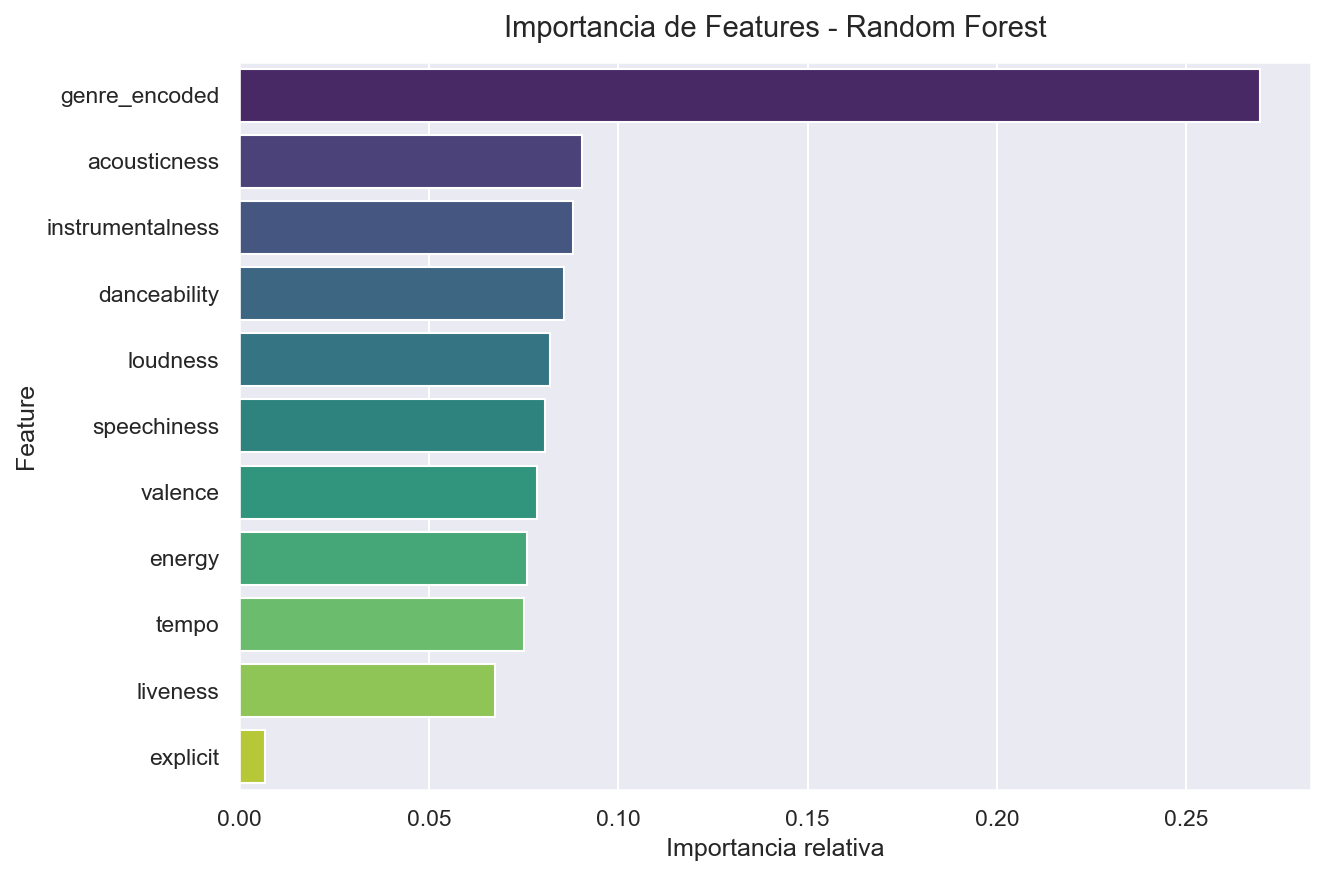

In [7]:
# Solo para Random Forest y Gradient Boosting
rf_model = modelos['RandomForest']

importance_df = pd.DataFrame(
    {'feature': FEATURES,
     'importance': rf_model.feature_importances_}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis', ax=ax)
ax.set_title('Importancia de Features - Random Forest', fontsize=14, pad=12)
ax.set_xlabel('Importancia relativa')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}feature_importance.png")
plt.show()


# 8. Predicciones vs reales

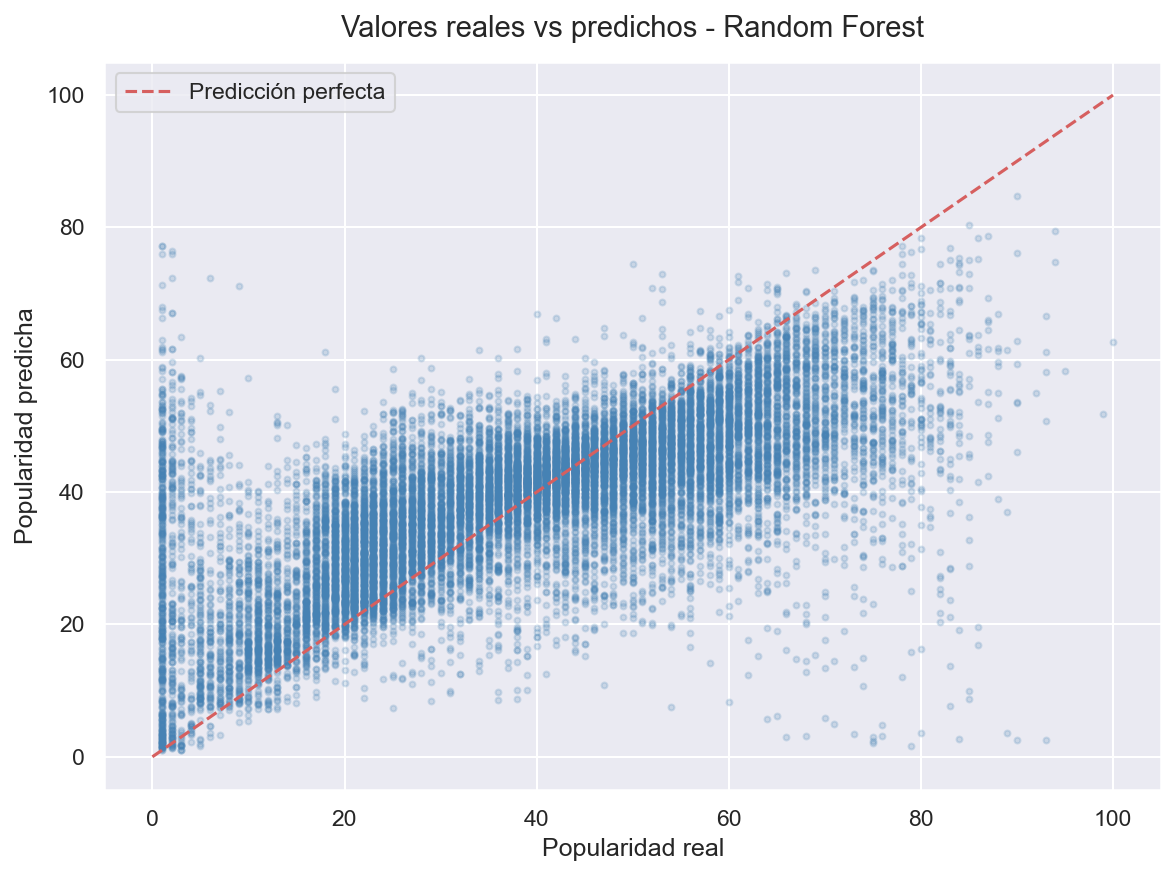

In [8]:
y_pred_rf = modelos['RandomForest'].predict(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred_rf, alpha=0.2, s=8, color='steelblue')
ax.plot([0, 100], [0, 100], 'r--', linewidth=1.5, label='Predicción perfecta')
ax.set_title('Valores reales vs predichos - Random Forest', fontsize=14, pad=12)
ax.set_xlabel('Popularidad real')
ax.set_ylabel('Popularidad predicha')
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}real_vs_pred_rf.png")
plt.show()

# 9. Distribución del error


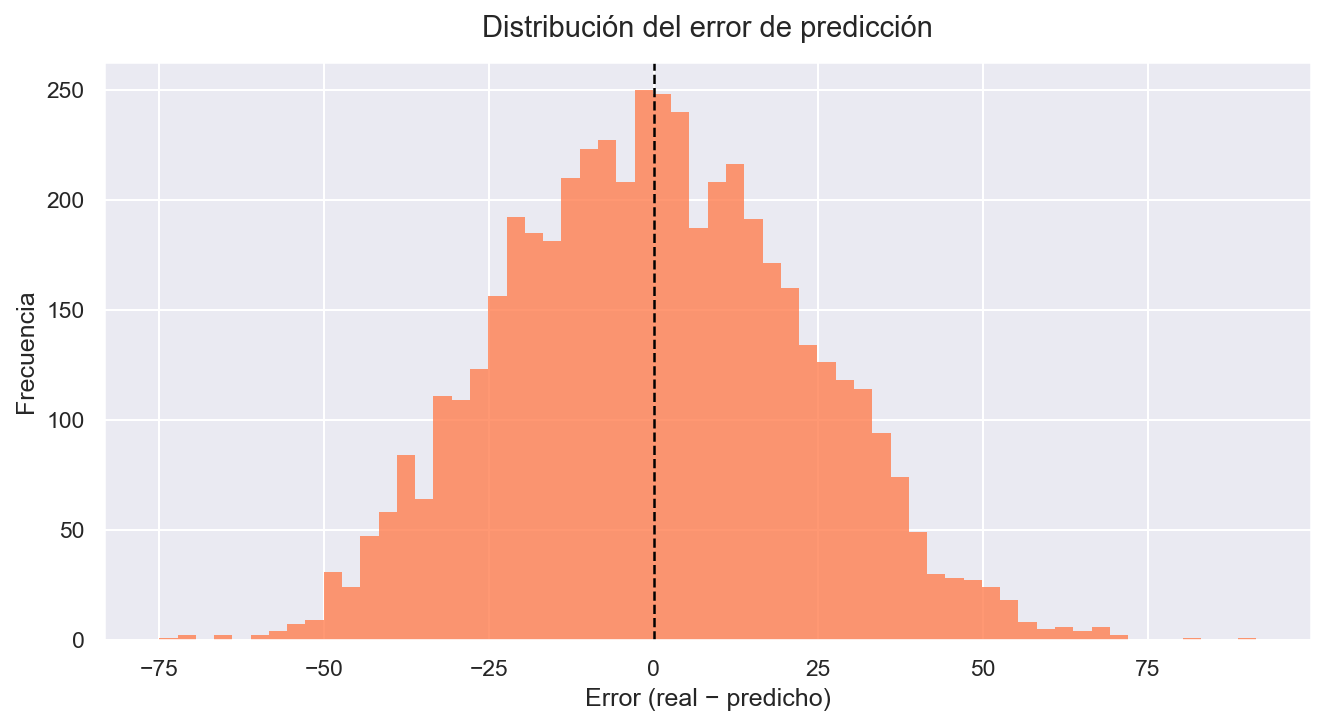

Error medio:   0.08
Desv. típica:  22.90


In [ ]:
errores = (y_test.values - y_pred_rf).ravel()

# Muestra aleatoria para el plot (suficiente para visualizar)
muestra = np.random.choice(errores, size=5000, replace=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(muestra, bins=60, color='coral', edgecolor='none', alpha=0.8)
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_title('Distribución del error de predicción', fontsize=14, pad=12)
ax.set_xlabel('Error (real - predicho)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}error_distribution.png")
plt.show()

print(f"Error medio:   {errores.mean():.2f}")
print(f"Desv. típica:  {errores.std():.2f}")

# 10. Prueba de predicción manual

In [18]:
# Simula lo que hará la API en fase 4
ejemplo = pd.DataFrame([{
    'danceability':      0.8,
    'energy':            0.7,
    'loudness':         -5.0,
    'speechiness':       0.05,
    'acousticness':      0.1,
    'instrumentalness':  0.0,
    'liveness':          0.1,
    'valence':           0.6,
    'tempo':            120.0,
    'explicit':          0,
    'genre_encoded':     le.transform(['pop'])[0]
}])

prediccion = mejor_modelo.predict(ejemplo)[0]
print(f"Predicción de popularidad para canción pop: {float(prediccion):.1f}/100")

Predicción de popularidad para canción pop: 43.3/100
